# Category Management & Product Portfolio Analytics

## Business Objective

This project analyzes a restaurant sales portfolio through the lens of Category Management.

The objective is to identify opportunities for:

- Assortment optimization
- Product portfolio management
- Pricing strategy
- Promotion effectiveness
- Demand planning
- Consumer behavior analysis

The analysis follows a framework similar to Category Management functions used in retail and e-commerce businesses.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")



In [2]:
# import the data

df = pd.read_csv("restaurant_sales_data.csv")

print(df.columns.tolist())

['date', 'restaurant_id', 'restaurant_type', 'menu_item_name', 'meal_type', 'key_ingredients_tags', 'typical_ingredient_cost', 'observed_market_price', 'actual_selling_price', 'quantity_sold', 'has_promotion', 'special_event', 'weather_condition']


In [3]:
df.head()


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10000 non-null  object 
 1   restaurant_id            10000 non-null  int64  
 2   restaurant_type          10000 non-null  object 
 3   menu_item_name           10000 non-null  object 
 4   meal_type                10000 non-null  object 
 5   key_ingredients_tags     10000 non-null  object 
 6   typical_ingredient_cost  10000 non-null  float64
 7   observed_market_price    10000 non-null  float64
 8   actual_selling_price     10000 non-null  float64
 9   quantity_sold            10000 non-null  int64  
 10  has_promotion            10000 non-null  bool   
 11  special_event            10000 non-null  bool   
 12  weather_condition        10000 non-null  object 
dtypes: bool(2), float64(3), int64(2), object(6)
memory usage: 879.0+ KB


In [3]:
 df['date'] = pd.to_datetime(df['date'])

# Data Preparation

Create business KPIs required for category performance analysis.

In [4]:
# Revenue
df['revenue'] = (
    df['actual_selling_price']
    * df['quantity_sold']
)

# Profit per unit
df['profit_per_unit'] = (
    df['actual_selling_price']
    - df['typical_ingredient_cost']
)

# Total profit
df['profit'] = (
    df['profit_per_unit']
    * df['quantity_sold']
)

# Margin %
df['margin_pct'] = (
    df['profit_per_unit']
    / df['actual_selling_price']
) * 100

# Price gap

df["price_gap_pct"] = (
    (
        df["actual_selling_price"]
        - df["observed_market_price"]
    )
    /
    df["observed_market_price"]
) * 100

# Executive Summary

Provide an overview of portfolio performance.

In [5]:
summary = pd.DataFrame({
    "Metric":[
        "Revenue",
        "Profit",
        "Average Margin %",
        "Categories",
        "SKUs"
    ],
    "Value":[
        round(df["revenue"].sum(),2),
        round(df["profit"].sum(),2),
        round(df["margin_pct"].mean(),2),
        df["restaurant_type"].nunique(),
        df["menu_item_name"].nunique()
    ]
})

summary

,Metric,Value
0,Revenue,32713418.10
1,Profit,24884682.90
2,Average Margin %,74.51
3,Categories,5.00
4,SKUs,14.00


### Key Findings

- The portfolio generated **€32.7M in revenue** and **€24.9M in profit**, demonstrating strong overall commercial performance.
- An average margin of **74.5%** indicates highly profitable products and effective pricing relative to costs.
- The assortment consists of **14 SKUs across 5 categories**, suggesting a focused portfolio with manageable complexity.
- On average, each SKU contributes approximately **€2.3M in revenue**, highlighting the importance of individual product performance.

### Business Implication

The portfolio exhibits strong profitability and a concentrated assortment structure. The next analysis focuses on identifying which categories and SKUs are driving revenue, profit, and future growth opportunities.

# Category Performance Analysis

Restaurant types are treated as product categories.

Business Question:

Which categories contribute most to portfolio revenue and profitability?

In [6]:
category_perf = (
    df.groupby("restaurant_type")
      .agg(
          Revenue=("revenue","sum"),
          Profit=("profit","sum"),
          Units=("quantity_sold","sum")
      )
      .sort_values(
          "Revenue",
          ascending=False
      )
)

category_perf["Profit Margin %"] = (
    category_perf["Profit"]
    / category_perf["Revenue"]
) * 100

category_perf.round(2)



,Revenue,Profit,Units,Profit Margin %
restaurant_type,,,,
Food Stall,9686508.42,6511692.82,1358811,67.22
Fine Dining,9061344.85,7643011.55,333260,84.35
Casual Dining,8900088.14,6954144.94,715603,78.14
Cafe,4470601.32,3362215.82,380311,75.21
Kopitiam,594875.37,413617.77,72019,69.53


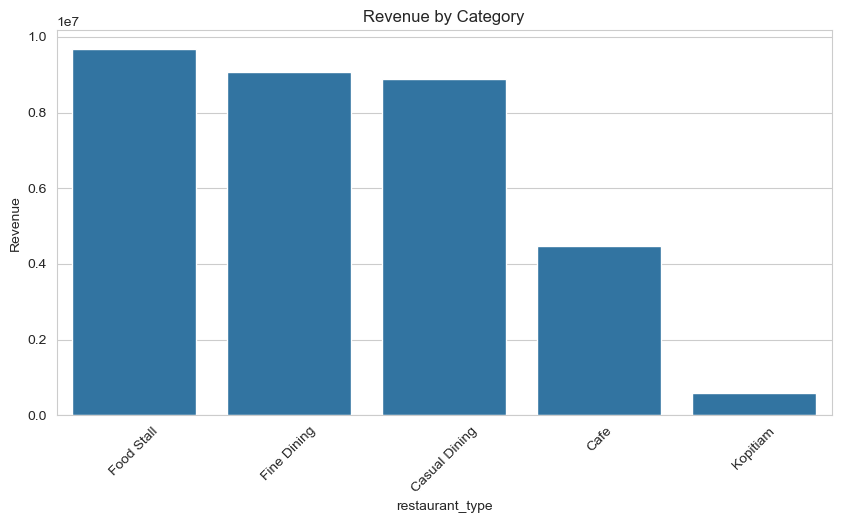

In [7]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=category_perf.index,
    y=category_perf["Revenue"]
)

plt.title("Revenue by Category")
plt.xticks(rotation=45)

plt.show()

### Key Findings

**Food Stall** is the largest category, generating **€9.7M revenue** and **1.36M units sold**, making it the primary driver of portfolio volume and revenue.

**Fine Dining** delivers the highest profitability with **€7.6M profit** and an **exceptional 84.35% margin**, indicating strong pricing power and premium positioning.

Casual Dining combines high revenue (€8.9M) with strong margins (78.14%), making it a stable and attractive core category.

Cafe contributes moderate revenue and profit, while Kopitiam remains a small niche category with limited overall portfolio impact.

### Business Implication

The portfolio follows a dual-category strategy: Food Stall drives scale and customer reach, while Fine Dining drives profitability. This suggests that future assortment decisions should focus on maintaining Food Stall's volume leadership while selectively expanding high-margin Fine Dining offerings to maximize portfolio profitability.


# SKU Performance Analysis

Menu items are treated as individual SKUs.

Business Question:

Which products drive portfolio performance?

In [8]:
sku_perf = (
    df.groupby("menu_item_name")
      .agg(
          Revenue=("revenue","sum"),
          Profit=("profit","sum"),
          Units=("quantity_sold","sum")
      )
      .sort_values(
          "Revenue",
          ascending=False
      )
)

sku_perf.head(10)

,Revenue,Profit,Units
menu_item_name,,,
Kaya Toast Set,5240719.63,3717236.83,544101
Chicken Chop,4762333.00,3885205.00,109641
Spaghetti Carbonara,4511648.25,3673622.25,93114
Beef Rendang,2919472.66,2325130.66,66038
Nasi Lemak,2423090.12,1856102.62,226795
Cendol,2213847.11,1604603.11,304622
Tandoori Chicken,2139956.04,1502620.04,91048
Teh Tarik,1954969.69,1376201.29,643076
Iced Lemon Tea,1400942.30,1118552.30,235325


In [9]:
sku_perf.tail(10)

,Revenue,Profit,Units
menu_item_name,,,
Nasi Lemak,2423090.12,1856102.62,226795
Cendol,2213847.11,1604603.11,304622
Tandoori Chicken,2139956.04,1502620.04,91048
Teh Tarik,1954969.69,1376201.29,643076
Iced Lemon Tea,1400942.30,1118552.30,235325
Mushroom Soup,1392304.64,1146730.64,70164
Char Kway Teow,1264686.61,943291.61,64279
Chicken Rice,1171895.17,860099.17,77949
Roti Canai,662168.77,432964.77,286505


In [10]:
sku_perf["Revenue Share %"] = (
    sku_perf["Revenue"]
    / sku_perf["Revenue"].sum()
) * 100

sku_perf.head(10)

,Revenue,Profit,Units,Revenue Share %
menu_item_name,,,,
Kaya Toast Set,5240719.63,3717236.83,544101,16.020092
Chicken Chop,4762333.00,3885205.00,109641,14.557736
Spaghetti Carbonara,4511648.25,3673622.25,93114,13.791430
Beef Rendang,2919472.66,2325130.66,66038,8.924389
Nasi Lemak,2423090.12,1856102.62,226795,7.407022
Cendol,2213847.11,1604603.11,304622,6.767398
Tandoori Chicken,2139956.04,1502620.04,91048,6.541524
Teh Tarik,1954969.69,1376201.29,643076,5.976048
Iced Lemon Tea,1400942.30,1118552.30,235325,4.282470


### Key Findings
**Kaya Toast Set** is the leading SKU, contributing **16.0% of total portfolio revenue**, making it the single most important product in the assortment.
The top three SKUs (Kaya Toast Set, Chicken Chop, and Spaghetti Carbonara) generate 44.4% of total revenue, indicating a high concentration of sales among a small number of products.
Chicken Chop and Spaghetti Carbonara combine strong revenue with high profitability, positioning them as key value-driving products within the portfolio.
Teh Tarik generates the highest sales volume (643K units) but contributes only 6.0% of revenue, suggesting a traffic-driving rather than profit-driving role.
Revenue contribution declines significantly after the top-performing SKUs, highlighting opportunities to improve the visibility and performance of mid-tier products.
Business Implication

The portfolio is moderately concentrated, with a small group of SKUs driving a large share of revenue. Assortment strategies should prioritize protecting top-performing products while developing mid-tier SKUs to reduce dependency on a few key revenue drivers.

# Product Portfolio Matrix

Products are classified based on Revenue and Profit.

Segments:

- Stars
- Cash Cows
- Hidden Gems
- Underperformers

In [11]:
portfolio = (
    df.groupby("menu_item_name")
      .agg(
          Revenue=("revenue","sum"),
          Profit=("profit","sum")
      )
)

revenue_cutoff = portfolio["Revenue"].median()
profit_cutoff = portfolio["Profit"].median()

In [12]:
def classify(row):

    if (
        row["Revenue"] >= revenue_cutoff
        and
        row["Profit"] >= profit_cutoff
    ):
        return "Star"

    elif row["Revenue"] >= revenue_cutoff:
        return "Cash Cow"

    elif row["Profit"] >= profit_cutoff:
        return "Hidden Gem"

    else:
        return "Underperformer"

In [13]:
portfolio["Segment"] = portfolio.apply(
    classify,
    axis=1
)

portfolio.head()

display(portfolio["Segment"].value_counts())
portfolio.groupby("Segment")[["Revenue","Profit"]].sum()


Segment
Star              7
Underperformer    7
Name: count, dtype: int64

,Revenue,Profit
Segment,,
Star,24211066.81,18564520.51
Underperformer,8502351.29,6320162.39


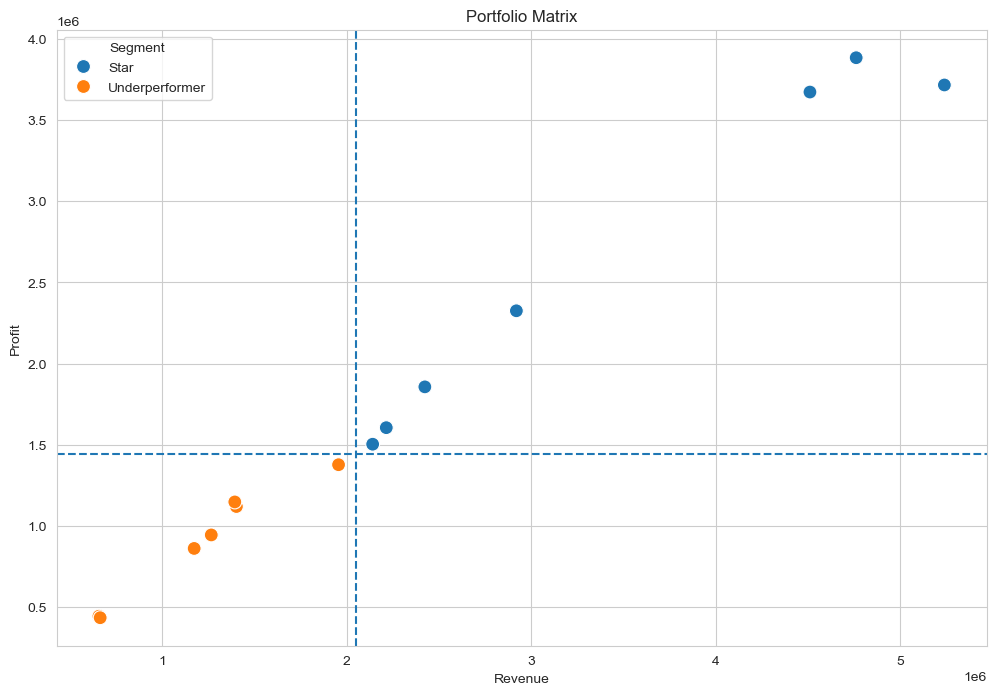

In [14]:
plt.figure(figsize=(12,8))

sns.scatterplot(
    data=portfolio,
    x="Revenue",
    y="Profit",
    hue="Segment",
    s=100
)

plt.axvline(revenue_cutoff,
            linestyle="--")

plt.axhline(profit_cutoff,
            linestyle="--")

plt.title("Portfolio Matrix")

plt.show()

### Key Findings

- The portfolio is evenly split between **7 Star products** and **7 Underperforming products**.
- Despite representing only **50% of the assortment**, Star products generate **74% of total revenue (€24.2M)** and **75% of total profit (€18.6M)**.
- Underperforming products account for half of the portfolio but contribute only **26% of revenue** and **25% of profit**, indicating significantly lower commercial impact.
- Revenue and profit are highly concentrated among a small group of high-performing products, highlighting their importance to overall portfolio success.

### Business Implication

The portfolio relies heavily on a limited number of Star products. Future assortment strategies should prioritize investment in these high-performing SKUs while reviewing Underperformers for repositioning, targeted promotions, or potential rationalization to improve portfolio productivity and resource allocation.

# Margin Optimization Analysis

Business Question:

Which products generate the highest profitability relative to revenue?

In [15]:
margin_analysis = (
    df.groupby("menu_item_name")
      .agg(
          Revenue=("revenue","sum"),
          Profit=("profit","sum")
      )
)

margin_analysis["Margin %"] = (
    margin_analysis["Profit"]
    /
    margin_analysis["Revenue"]
) * 100

margin_analysis.sort_values(
    "Margin %",
    ascending=False
).head(10)

,Revenue,Profit,Margin %
menu_item_name,,,
Mushroom Soup,1392304.64,1146730.64,82.362050
Chicken Chop,4762333.00,3885205.00,81.581968
Spaghetti Carbonara,4511648.25,3673622.25,81.425281
Iced Lemon Tea,1400942.30,1118552.30,79.842853
Beef Rendang,2919472.66,2325130.66,79.642145
Nasi Lemak,2423090.12,1856102.62,76.600643
Char Kway Teow,1264686.61,943291.61,74.586985
Chicken Rice,1171895.17,860099.17,73.393866
Cendol,2213847.11,1604603.11,72.480304


### Key Findings

- **Mushroom Soup** is the highest-margin SKU, achieving an **82.4% margin**, indicating strong profitability relative to its sales performance.
- **Chicken Chop** and **Spaghetti Carbonara** combine both high margins (**81%+**) and high revenue, making them the most commercially attractive products in the portfolio.
- Premium main-course items consistently outperform in profitability, with **Beef Rendang**, **Chicken Chop**, and **Spaghetti Carbonara** all delivering margins close to or above **80%**.
- While **Kaya Toast Set** is the largest revenue contributor, its margin (**70.9%**) is lower than several other top-performing products, suggesting potential opportunities for pricing or cost optimization.
- The margin spread across products is relatively narrow, indicating a generally healthy and profitable assortment.

### Business Implication

High-margin products such as **Chicken Chop**, **Spaghetti Carbonara**, and **Beef Rendang** should be prioritized in promotional campaigns and assortment expansion strategies. Additionally, reviewing the pricing and cost structure of high-volume products like **Kaya Toast Set** could further improve overall portfolio profitability.

# Competitive Pricing Analysis

Business Question:

How competitive are current selling prices compared to market prices?

In [16]:
pricing = (
    df.groupby("menu_item_name")
      .agg(
          AvgPriceGap=("price_gap_pct","mean"),
          Revenue=("revenue","sum")
      )
)

pricing.head()

,AvgPriceGap,Revenue
menu_item_name,,
Beef Rendang,60.095551,2919472.66
Cendol,50.025528,2213847.11
Char Kway Teow,67.201800,1264686.61
Chicken Chop,50.926013,4762333.00
Chicken Rice,59.595212,1171895.17


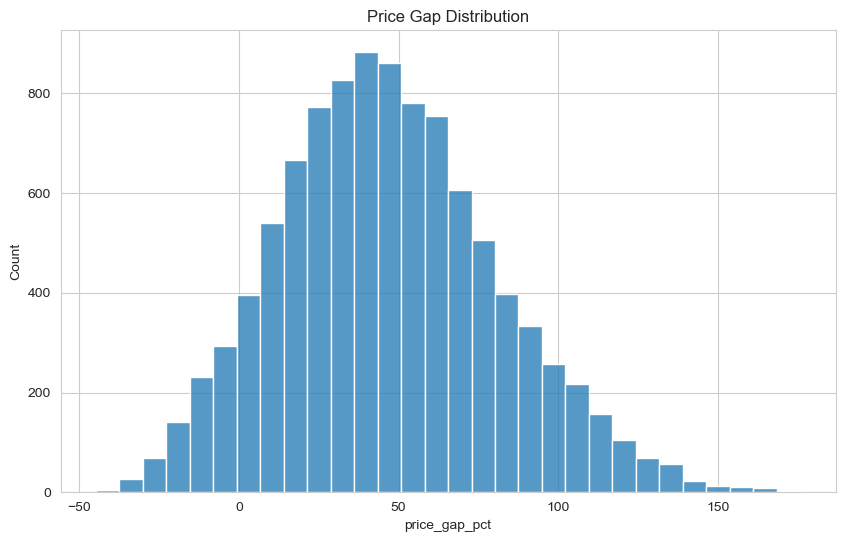

In [17]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["price_gap_pct"],
    bins=30
)

plt.title(
    "Price Gap Distribution"
)

plt.show()

### Key Findings

- The price gap distribution is heavily skewed toward positive values, indicating that most products are sold at prices **above the observed market average**.
- The majority of transactions fall within a **20%–80% price premium range**, suggesting strong pricing power across the portfolio.
- Several top-performing SKUs maintain substantial price premiums while continuing to generate strong revenue, indicating that customers are willing to pay for perceived value or product differentiation.
- **Char Kway Teow (67.2%)** and **Beef Rendang (60.1%)** command the highest average price premiums, while **Chicken Chop (50.9%)** and **Cendol (50.0%)** also maintain significant premiums without negatively impacting sales performance.
- The absence of a large concentration around zero suggests that the portfolio is not competing primarily on price but rather on product value and positioning.

### Business Implication

The portfolio demonstrates strong pricing power, with many products successfully sold at substantial premiums relative to market benchmarks. Rather than competing through discounts, future pricing strategies should focus on preserving value perception while monitoring highly premium-priced products to ensure long-term demand sustainability.

The combination of high margins (70%–82%) and positive price gaps (50%–67%) suggests that product differentiation and perceived value are likely stronger drivers of performance than price competitiveness.

# Promotion Effectiveness

Business Question:

Do promotions generate additional demand and revenue?

In [18]:

promotion= df.groupby("has_promotion").agg(
    Avg_Revenue=("revenue","mean"),
    Avg_Profit=("profit","mean"),
    Avg_Units=("quantity_sold","mean")
)
promotion

,Avg_Revenue,Avg_Profit,Avg_Units
has_promotion,,,
False,3104.922378,2417.967815,251.433545
True,4215.866515,2888.598491,482.186916


In [19]:
pct_change = (
    (promotion.loc[True] - promotion.loc[False]) 
    / promotion.loc[False]
) * 100

pct_change

Avg_Revenue    35.780094
Avg_Profit     19.463893
Avg_Units      91.775093
dtype: float64

## Promotion Impact Summary

| Metric | No Promotion | Promotion | % Change |
|--------|-------------|-----------|----------|
| Avg Revenue | 3104.92 | 4215.87 | +35.8% |
| Avg Profit | 2417.97 | 2888.60 | +19.5% |
| Avg Units | 251.43 | 482.19 | +91.7% |

## Key Insights

- Promotions significantly increase **sales volume** (+91.7% units).
- **Revenue growth (+35.8%) is lower than unit growth**, suggesting lower price per unit during promotions.
- **Profit still increases (+19.5%)**, meaning promotions are overall profitable.
- Growth is primarily **volume-driven rather than price-driven**.

## Strategic Takeaway

Promotions are effective for driving demand and increasing total profit, but they likely reduce **unit margins**, increasing reliance on discount-driven sales.

# Seasonal Demand Planning

Business Question:

Which periods experience the highest demand?

In [20]:
monthly_sales = (
    df.groupby(
        df["date"].dt.month
    )["revenue"]
    .sum()
)

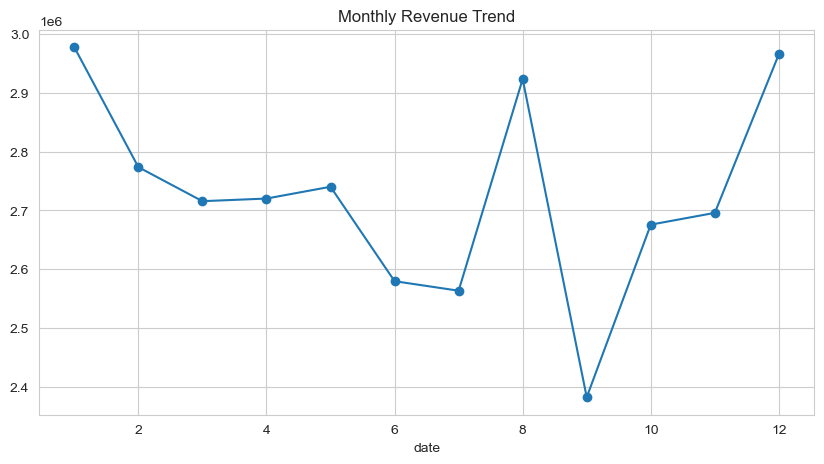

In [21]:
plt.figure(figsize=(10,5))

monthly_sales.plot(
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.show()

### Key Findings

- Revenue remains relatively stable throughout the year, ranging between approximately **€2.4M and €3.0M per month**, indicating consistent demand across the portfolio.
- The strongest revenue periods occur in **January, August, and December**, each generating close to **€3.0M**, suggesting seasonal demand peaks.
- Revenue declines gradually during the middle of the year, reaching its lowest point in **September (~€2.4M)** before recovering in the final quarter.
- The sharp rebound from September to December indicates increased consumer spending and stronger purchasing activity toward year-end.

### Business Implication

The portfolio demonstrates clear seasonality, with peak demand concentrated at the beginning and end of the year. Inventory planning, promotional campaigns, and assortment launches should be aligned with these high-demand periods, while mid-year performance may benefit from targeted marketing initiatives to stimulate sales.

The identified demand peaks suggest opportunities for seasonal assortment planning and targeted campaign execution, ensuring product availability during high-demand periods while optimizing inventory during slower months.

# Consumer Behavior Analysis

Evaluate external factors influencing demand.

In [22]:
weather = (
    df.groupby("weather_condition")
      .agg(
          Revenue=("revenue","sum"),
          Units=("quantity_sold","sum")
      )
)

weather

,Revenue,Units
weather_condition,,
Cloudy,9934265.50,856987
Rainy,6397461.54,527936
Sunny,16381691.06,1475081


In [23]:
events = (
    df.groupby("special_event")
      .agg(
          Revenue=("revenue","sum"),
          Profit=("profit","sum")
      )
)

events

,Revenue,Profit
special_event,,
False,30513541.33,23211037.33
True,2199876.77,1673645.57


### Key Findings

- **Sunny weather** generates the highest demand, contributing **€16.4M revenue** and **1.48M units sold**, accounting for approximately **50% of total portfolio revenue**.
- Revenue declines under **Cloudy (€9.9M)** and **Rainy (€6.4M)** conditions, indicating that weather has a measurable impact on consumer purchasing behavior.
- The majority of revenue (**€30.5M, 93%**) is generated during non-special-event periods, suggesting that the portfolio performs consistently without relying heavily on event-driven demand.
- Although special events contribute a relatively small share of total revenue (**€2.2M**), they still generate substantial profit (**€1.7M**), indicating potential opportunities for targeted campaigns during key occasions.

### Business Implication

Consumer demand is influenced by external factors, particularly weather conditions. Sunny periods represent the strongest sales opportunity and should be supported with inventory availability and targeted marketing initiatives. Additionally, while special events are not the primary revenue driver, they offer opportunities for seasonal campaigns and assortment activations to capture incremental demand.

# Assortment Recommendations

Translate analytical findings into business actions.

In [24]:
portfolio["Recommendation"] = (
    portfolio["Segment"]
      .map({
          "Star":"Expand Assortment",
          "Cash Cow":"Maintain",
          "Hidden Gem":"Increase Visibility",
          "Underperformer":"Review for Delisting"
      })
)

portfolio[
    ["Segment",
     "Recommendation"]
].head(20)

,Segment,Recommendation
menu_item_name,,
Beef Rendang,Star,Expand Assortment
Cendol,Star,Expand Assortment
Char Kway Teow,Underperformer,Review for Delisting
Chicken Chop,Star,Expand Assortment
Chicken Rice,Underperformer,Review for Delisting
Iced Lemon Tea,Underperformer,Review for Delisting
Kaya Toast Set,Star,Expand Assortment
Laksa,Underperformer,Review for Delisting
Mushroom Soup,Underperformer,Review for Delisting


## Assortment Strategy & Portfolio Recommendations

### Key Findings

- **7 SKUs** have been identified as **Star products**, demonstrating strong performance in both revenue and profitability.
- Key Star products include **Kaya Toast Set, Chicken Chop, Spaghetti Carbonara, Beef Rendang, Nasi Lemak, Tandoori Chicken, and Cendol**.
- The remaining **7 SKUs** are classified as **Underperformers**, generating below-average revenue and profit relative to the portfolio.
- Several underperforming products, including **Laksa, Roti Canai, Chicken Rice, and Char Kway Teow**, contribute limited commercial value and should be reviewed for their strategic role within the assortment.

### Assortment Recommendations

#### Expand Assortment
Focus investment, visibility, and inventory allocation on:

- Kaya Toast Set
- Chicken Chop
- Spaghetti Carbonara
- Beef Rendang
- Nasi Lemak
- Tandoori Chicken
- Cendol

These products represent the strongest growth opportunities and are the primary drivers of portfolio revenue and profitability.

#### Review for Optimization or Delisting
Evaluate the commercial relevance of:

- Char Kway Teow
- Chicken Rice
- Iced Lemon Tea
- Laksa
- Mushroom Soup
- Roti Canai
- Teh Tarik

Before delisting, further analysis should assess whether these products play a strategic role in customer acquisition, basket building, or category completeness.

### Business Implication

The portfolio shows a clear performance imbalance, with Star products generating the majority of revenue and profit. A more focused assortment strategy centered around high-performing SKUs can improve portfolio productivity, optimize resource allocation, and support long-term profitable growth.

# Final Business Recommendations

Based on the analysis of category performance, SKU contribution, pricing, promotions, seasonality, and consumer behavior, the following recommendations are proposed to optimize portfolio performance and support sustainable growth.

## 1. Strengthen High-Performing Categories

- Continue investing in **Food Stall**, which generates the highest revenue and sales volume.
- Expand premium offerings within **Fine Dining**, which delivers the highest profit margin (84.4%).
- Maintain **Casual Dining** as a core category due to its balanced contribution to both revenue and profitability.

## 2. Prioritize Star Products

The portfolio is heavily dependent on a small group of high-performing products that generate **74% of total revenue and 75% of total profit**.

Focus assortment expansion, visibility, and inventory allocation on:

- Kaya Toast Set
- Chicken Chop
- Spaghetti Carbonara
- Beef Rendang
- Nasi Lemak
- Tandoori Chicken
- Cendol

These products should form the foundation of future growth strategies.

## 3. Optimize the Long-Tail Assortment

Several products contribute relatively low commercial value despite occupying portfolio space.

Review the performance and strategic role of:

- Char Kway Teow
- Chicken Rice
- Iced Lemon Tea
- Laksa
- Mushroom Soup
- Roti Canai
- Teh Tarik

Potential actions include:
- Product repositioning
- Recipe or pricing optimization
- Targeted promotions
- Assortment rationalization where justified

## 4. Leverage Pricing Power

The portfolio demonstrates strong pricing power, with most products sold above observed market prices while maintaining healthy demand.

Recommended actions:

- Preserve premium pricing for high-performing products.
- Monitor highly premium-priced items to ensure demand remains stable.
- Optimize pricing for high-volume products such as Kaya Toast Set to further improve profitability.

## 5. Improve Promotion Efficiency

Promotional sales contribute only **19% of total revenue**, while non-promotional sales generate the majority of portfolio profit.

Recommended actions:

- Shift from broad discounting to targeted promotions.
- Prioritize promotions for strategic growth products and high-margin SKUs.
- Evaluate promotion effectiveness based on incremental revenue and profit generation.

## 6. Align Assortment with Seasonal Demand

Revenue peaks occur during:

- January
- August
- December

Recommended actions:

- Increase inventory availability ahead of peak-demand periods.
- Schedule major assortment launches and marketing campaigns during these months.
- Introduce targeted initiatives during slower mid-year periods to stimulate demand.

## 7. Utilize Consumer Behavior Insights

Consumer demand is strongly influenced by external factors.

Key observations:

- Sunny weather generates approximately 50% of total revenue.
- Special events contribute incremental revenue and profit opportunities.

Recommended actions:

- Incorporate weather and event-based forecasting into planning processes.
- Develop seasonal campaigns tailored to high-demand periods and special occasions.

## Overall Conclusion

The portfolio demonstrates strong commercial performance, high profitability, and effective pricing power. However, revenue and profit are concentrated among a limited number of Star products. Future growth should focus on expanding high-performing SKUs, optimizing underperforming products, leveraging pricing strength, and aligning commercial activities with seasonal and consumer demand patterns.

By implementing these strategies, the portfolio can improve assortment productivity, maximize profitability, and support long-term sustainable growth.